In [1]:
import sys
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from hyperopt import fmin, tpe, hp, Trials
from scipy.integrate import solve_ivp
import warnings
warnings.filterwarnings("ignore")

In [2]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
# --------------- Import custom modules  --------------- #
from model.dualscale import PEMFC
from model.coefficients import *
from model.kinetic_eq import *
from modules.signals import generate_step_load
from config.initialize import *
from config.settings import *

In [3]:
# Setup load profile
tstart     = 0.0      # start of each period                    [s]
tend       = 6.0    # end of each period                      [s]
i_low      = 0.002e4      # baseline current density                [A/m^2]
i_high     = 1.2e4    # plateau current density                 [A/m^2]
tau_switch = 1.5    # time (within a period) the ramp BEGINS  [s]
t_switch   = 1   # effective ramp duration                 [s]
step_load = generate_step_load(tstart, tend, i_low, i_high, tau_switch, t_switch)

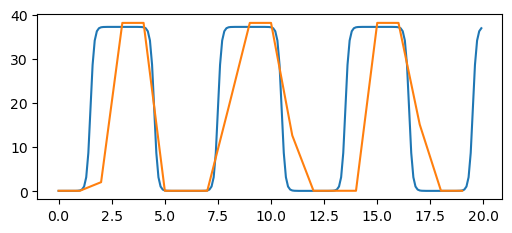

In [4]:
expdata_AST = pd.read_csv("D:/Datasets/AST/csv/AST_combined.csv")
plt.figure(figsize=(6, 2.4))
plt.plot(np.arange(0, 20., 0.1), [step_load(i)*31e-4 for i in np.arange(0, 20, 0.1)])
plt.plot(expdata_AST["I_LOAD_A"].iloc[60003:60023].tolist())

## Dual scale solution
###  Setup the operation condition

An initial solution is obtained for the value initilization in the  AST simulation. 

In [5]:
operating_inputs["current_density"] = lambda x: 0.2e4
operating_inputs["Phi_c_des"] = 0.85
operating_inputs["Sa"] = 1.2
operating_inputs["Sc"] = 2
operating_inputs["Pa_des"] = 1.8e5
operating_inputs["Pc_des"] = 1.8e5
operating_inputs["Tfc"] = 353.15
model = PEMFC(param=parameters, operating_inputs=operating_inputs,
              variable_names=solver_variable_names, flux_names=solver_flux_names)
solution_init = init_x(operating_inputs, parameters)
S = model.jac_sparsity(solution_init)
sol = solve_ivp(model.dxdt, t_span=(0,60), y0=solution_init, method='BDF', max_step=0.1, jac_sparsity=S, atol = 1e-4)

### Dual-scale model simulation

In [ ]:
operating_inputs["current_density"] = step_load
S = model.jac_sparsity(solution_init)
sol = solve_ivp(model.dxdt, t_span=(0, 5000 * 6 * 3), y0=solution_init, method='BDF', max_step=0.1, jac_sparsity=S, atol = 1e-4)
model._recovery(sol)

To prevent the simulation from long time execution, put all initialized variables in the same folder of the model

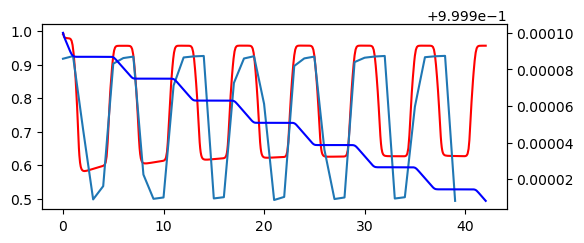

In [ ]:
fig, ax =  plt.subplots(figsize=(6,2.4))
ax.plot(model.variables["t"][: 600], model.echem_traj["Ucell"][: 600], color = "r")
ax.plot(expdata_AST["VFC_10V"].iloc[60003:60043].to_numpy()/22)
ax.twinx().plot(model.variables["t"][: 600], model.echem_traj["S_N"][: 600], color = "b")

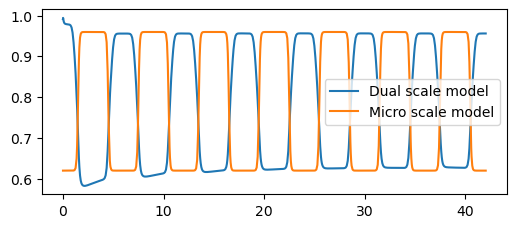

In [ ]:
def ucell_sw(t):
    t = t%6
    t_stop = 6
    iload_rise =  0.17 * np.tanh(8*(t - t_stop / 4)) + 0.31
    iload_drop =  -0.17 * np.tanh(8*(t - t_stop * 3 / 4)) +0.31
    return iload_rise  + iload_drop
fig, ax =  plt.subplots(figsize=(6,2.4))
ax.plot(model.variables["t"][: 600], model.echem_traj["Ucell"][: 600], label = "Dual scale model")
ax.plot(model.variables["t"][: 600], [ucell_sw(t) for t in model.variables["t"][: 600]], label = "Micro scale model")
ax.legend()

Text(0, 0.5, 'Density')

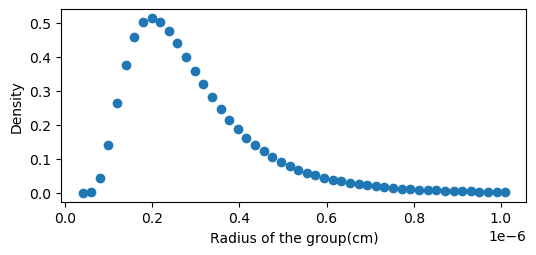

In [ ]:
n_group_ptParticle = parameters["n_group_pt"]
r_m = model.parameters["r_m"]

def initPRD(resolution=100, rmin=1e-8, rmax=1e-6, std=0.549, mu=0.538):
    radius = np.linspace(rmin, rmax, resolution)
    pdf = 1/(std*np.sqrt(4*np.pi)) * np.exp(-(np.log(radius*1e7)-mu)**2/(std**2*2))
    return pdf

class ccl():
    
    def __init__(self):
        self.Ucell = ucell_sw
        self.Tfc = 353.15
        self.parameters = {"krdp": krdp, "k1":k1, "k1_ref":k1_ref, "k2": k2, "k2_ref": k2_ref, "k3": k3, "k4": k4, "k5":k5, "k4_ref":kdet_ref}
        self.prd0 = initPRD(resolution=n_group_ptParticle)
        
    def dxdt(self, t, x):
            
        C_Pt2_ccl = x[0]
        theta_CCL = x[1:1+len(r_m)]
        prd = x[-len(r_m):]
        u = self.Ucell(t)
        
        # CCL kinetic
        # 0.043 + 17.81*0.85 - 39.85*0.85**2 + 36*0.85**3 = 8.5
        R0 = (2*9.09*0.2e-4)/(R*353)
        C_H_CCL = Cproton_CCL(lambda_w=8.5)
        kdis = PtDissolution(u, self.Tfc, C_Pt2_ccl, theta_CCL)
        kox = PtOxidation(u, self.Tfc, C_H_CCL, theta_CCL)
        kcdis = PtOxideDissolution(theta_CCL, C_H_CCL)
        kdet = PtDetachment(u, self.Tfc, r_m)
        drdt = Vm_Pt * self.parameters["krdp"] * C_Pt2_ccl * np.exp(-R0 / r_m) - Vm_Pt * (kdis + kox) * Cpt2_ref * np.exp(R0 / r_m)
        M_Pt0 = 4 / 3 * np.pi * rho_Pt * trapezoid(y=self.prd0 * r_m ** 3, x=r_m)
        dMdisdt = 4 * np.pi * rho_Pt * trapezoid(y=prd * r_m ** 2 * drdt, x=r_m)
        dMcdisdt = 4 * np.pi * rho_Pt * trapezoid(y=prd * r_m ** 2 * kcdis, x=r_m)
        dC_Pt2_ccl = -3.33 / M_Pt * (dMdisdt - dMcdisdt) / M_Pt0
        dfdt = -np.gradient(prd * drdt, r_m) - kdet * prd
        dthetadt = (((kox - kcdis) / GAMMA_max) - (2 * theta_CCL / r_m) * drdt)
        
        dxdt = [0]*(1+len(r_m)*2)
        dxdt[0] = dC_Pt2_ccl
        dxdt[1:1+len(r_m)] = dthetadt
        dxdt[-len(r_m):] = dfdt
        
        return dxdt
plt.figure(figsize=(6,2.5))
plt.scatter(r_m,initPRD(len(r_m)))
plt.xlabel("Radius of the group(cm)")
plt.ylabel("Density")

## Micro scale model simulation

Catalyst degradation

In [ ]:
from model.coefficients import *
micro_model = ccl()
x_init = [0] + [0]*len(r_m) + micro_model.prd0.tolist()
sol_micro_CL = solve_ivp(fun=micro_model.dxdt, y0 = x_init, t_span=(0, 5000 * 6 * 3),max_step=1e-1, method='BDF')
sim_data = [getECSA(sol_micro_CL.y[-len(r_m):, i], r_m)/getECSA(micro_model.prd0, r_m) for i in range(len(sol_micro_CL.t))]

Membrane degradation

In [ ]:
def dHdt(t, x):

    PO2_ca = 6 * R *  operating_inputs['Tfc']
    A_1 = 5.5e-13  # Fitted constant (ug/(H m-2))
    alpha_eq = 0.52  # Equivalent transfer coefficient
    e_M0 = 1.2e-5  # The initial membrane thickness (m)
    E_a = 75e3  # The equivalent activation energy (J/mol)
    T0 = 273.15 + 95
    P0 = 1e5
    ffr = A_1 * (PO2_ca/P0) * (e_M0 / x) * np.exp(alpha_eq * F * ucell_sw(t) / (R * operating_inputs['Tfc'])) * np.exp(-E_a / R * (1 / operating_inputs['Tfc'] - 1 / T0))
    return -20.8 / (0.82 * 1980e3) *ffr
sol_micro_MEM = solve_ivp(fun=dHdt, y0 = [parameters["Hmem"]], t_span=(0,sol_micro_CL.t[-1]),max_step = 1e-1, method='BDF')

Text(0, 0.5, 'ECSA')

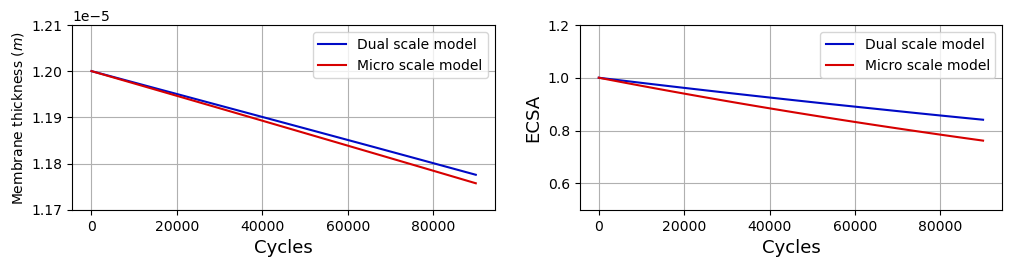

In [ ]:
fig, ax = plt.subplots(figsize = (12, 2.4), nrows=1, ncols=2)

ax[0].plot(model.variables["t"], model.variables["delta_mem"], label = "Dual scale model", color ="#000AC6")
ax[0].plot(sol_micro_MEM.t, sol_micro_MEM.y[0], label = "Micro scale model", color = "#d70000")
ax[0].grid()
ax[0].legend()
ax[0].set_ylim(1.17e-5, 1.21e-5)
ax[0].set_ylabel(f"Membrane thickness ($m$)")
ax[0].set_xlabel("Cycles",fontsize=13)
ax[1].plot(model.variables["t"], model.echem_traj["S_N"], label = "Dual scale model", color ="#000AC6")
ax[1].plot(sol_micro_CL.t, sim_data, label = "Micro scale model", color = "#d70000")
ax[1].legend()
ax[1].set_ylim(0.5, 1.2)
ax[1].grid()
ax[1].set_xlabel("Cycles",fontsize=13)
ax[1].set_ylabel("ECSA",fontsize=13)